In [5]:
import sys
path_lock = False
if not path_lock:
    sys.path.append("../")
    path_lock = True
    
import numpy as np
import ffiting as ff

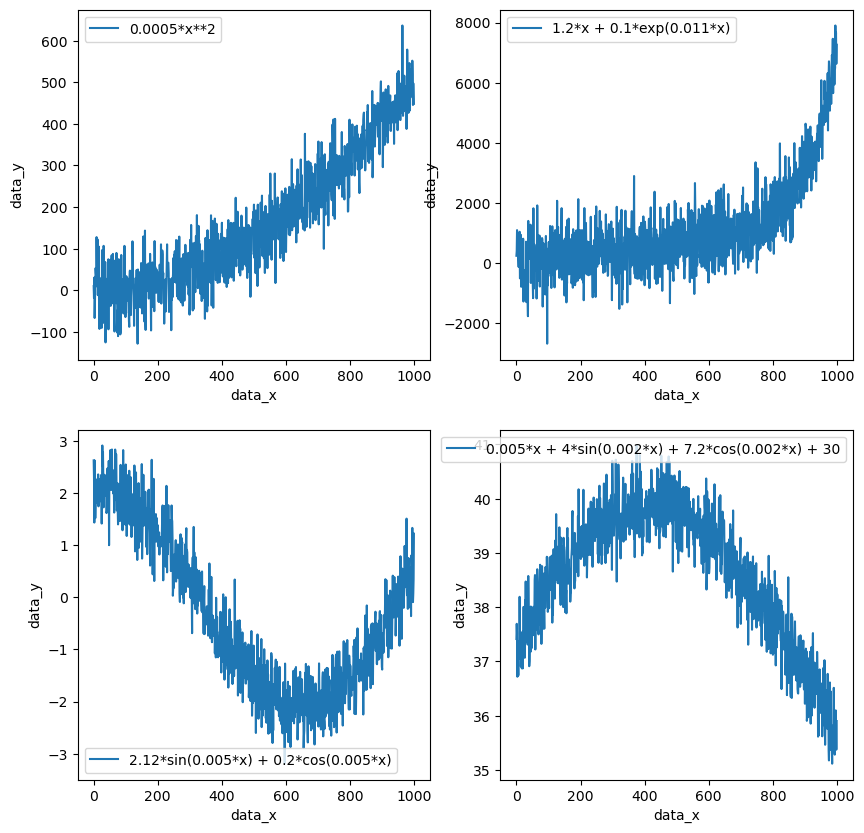

In [6]:
data_x: np.ndarray = np.arange(0, 1000)

poly_md = ff.Generators.ranked_poly([0, 0, 0.0005])
exp_md = ff.Generators.exponential([0, 1.2, 0.1, 0.011])
trans_md = ff.Generators.transcendental([0.2, 0.005, 2.12])
lint_md = ff.Generators.combined_lint([30, 0.005, 4, 0.002, 7.2, 0.01])

data_poly_train = ff.apply_noise(poly_md(data_x))
data_exp_train = ff.apply_noise(exp_md(data_x))
data_trans_train = ff.apply_noise(trans_md(data_x))
data_lint_train = ff.apply_noise(lint_md(data_x))

ff.sep_plot(
    ff.PlotRequest(data_poly_train, poly_md.label),
    ff.PlotRequest(data_exp_train, exp_md.label),
    ff.PlotRequest(data_trans_train, trans_md.label),
    ff.PlotRequest(data_lint_train, lint_md.label),
)

The balance was formed:


-a0 - a2 + c0

-H*a1 - H*a2*a3 + H*c1

-H**2*a2*a3**2/2 + H**2*c2

-H**3*a2*a3**3/6 + H**3*c3

...

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: (-17019.9980902511, 4.40455973977716, 17019.9596113909, -0.000260486695536512)'

'Metrics:'

Residual SE: 2.063
Mean SE: 4.249
Linear Div: 1860.879
Standard Div: 150.719
Standard Err: 4.766
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


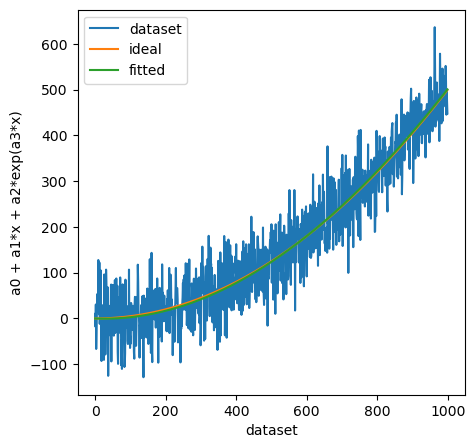

In [12]:
model = ff.Models.exponential(ff.FittingModes.DSB)
model.options.raise_rank = False
fitted = model.fit(data_poly_train)
data_fitted = fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {fitted.coeffs}")

display("Metrics:")
data_ideal = poly_md(data_x)
print(ff.get_metrics_m(model, data_ideal))

ff.multi_plot(
    ff.PlotRequest(data_poly_train, "dataset"),
    ff.PlotRequest(data_ideal, "ideal"),
    ff.PlotRequest(model.data_fit, "fitted"),
    label_y=model.options.expr_raw,
    label_x="dataset"
)

'Metrics Prediction:'

Residual SE: 43.979
Mean SE: 1930.247
Linear Div: 32254.081
Standard Div: 405.068
Standard Err: 12.809
Determination Coeff: 0.988
Correlation Coeff: 1.000
Concordance Coeff: 0.996


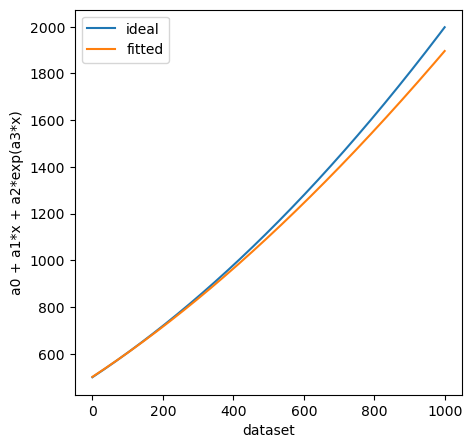

In [11]:
data_x_test = np.arange(1000,2000)
data_fitted_test = fitted(data_x_test)

display("Metrics Prediction:")
data_ideal_test = poly_md(data_x_test)
print(ff.get_metrics(data_fitted_test, data_ideal_test))

ff.multi_plot(
    ff.PlotRequest(data_ideal_test, "ideal"),
    ff.PlotRequest(data_fitted_test, "fitted"),
    label_y=model.options.expr_raw,
    label_x="dataset"
)